# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**AlexNet Augmented Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating an AlexNet model on the Pneumonia dataset with data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [3]:
# Import utility libraries
import os
import sys
import time
from datetime import datetime
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Suppress TensorFlow warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'    # 0=all, 1=info, 2=warning, 3=error
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN optimizations for reproducibility

# Disable verbose output from TensorFlow during training
tf_verbosity = 1  # 0 = silent, 1 = progress bar, 2 = one line per epoch

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.alexnet_utils import build_alexnet, DropoutRateScheduler
from utils.train_utils import get_callbacks
from utils.eval_utils import evaluate_model
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix
from utils.logger_utils import ModelLogger

# Core Variables

In [4]:
# Global seed for reproducibility
RANDOM_SEED = 42

# Path variables
DATA_PATH = '../data/'                                          # Path to the dataset
OUTPUT_PATH = '../output/'                                      # Path to save output files
MODEL_PATH = OUTPUT_PATH + 'models/'                            # Path to save the model
MODEL_NAME = 'alexnet_augmented'                                # Name of the model to be saved
LOG_PATH = OUTPUT_PATH + 'logs/'+ MODEL_NAME + '_info.json'     # Path to save model metrics

# Ensure directories exist
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)

In [77]:
# Training parameters
EPOCHS = 100                # Number of epochs to train
BATCH_SIZE = 96             # Batch size for training
LEARNING_RATE = 0.001       # Learning rate for the optimizer

# Dropout parameters
DROPOUT_MODE = "custom"     # Dropout mode: "fixed" or "custom"
DROPOUT_RATE = 0.3          # Fixed dropout rate
DROPOUT_RATE_START = 0.5    # Starting rate for scheduler
DROPOUT_RATE_END = 0.3      # Ending rate for scheduler

# Model selection parameters
CHOSEN_METRIC = 'val_AUC'   # Metric to be used for model selection
MODE = 'max'                # Whether to maximize or minimize the chosen metric

# Final model path
if DROPOUT_MODE == "fixed":
    FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_b{BATCH_SIZE}_lr{LEARNING_RATE}_dr{DROPOUT_RATE}_pneumonia_model.keras'
elif DROPOUT_MODE == "custom":
    FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_b{BATCH_SIZE}_lr{LEARNING_RATE}_dr{DROPOUT_RATE_START}_{DROPOUT_RATE_END}_pneumonia_model.keras'

# Create model logger
logger = ModelLogger()

# Data Loading & Preprocessing

In [78]:
train_dataset, (test_images, test_labels), (val_images, val_labels) = load_and_preprocess_data(
        DATA_PATH,
        augment=True,
        batch_size=BATCH_SIZE,
        seed=RANDOM_SEED
    )


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)

Applying data augmentation to training data...


# AlexNet Model

## Creation & Compilation

In [79]:
# Initialize model info for logging
model_info = {
    "model_name": MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "dropout_mode": DROPOUT_MODE,
    "dropout_rate": DROPOUT_RATE if DROPOUT_MODE == "fixed" else None,
    "dropout_start": DROPOUT_RATE_START if DROPOUT_MODE == "custom" else None,
    "dropout_end": DROPOUT_RATE_END if DROPOUT_MODE == "custom" else None,
    "random_seed": RANDOM_SEED
}

# Initialize logger with model info
logger.initialize_run(model_info)

In [80]:
# Create and compile model
if DROPOUT_MODE == "fixed":
    model = build_alexnet(dropout_rate=DROPOUT_RATE)
elif DROPOUT_MODE == "custom":
    model = build_alexnet(dropout_rate=DROPOUT_RATE_START)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 28, 28, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 28, 28, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_56 (Activation)      │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 14, 14, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_57 (Activation)      │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_58 (Activation)      │ (None, 7, 7, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_59 (Activation)      │ (None, 7, 7, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_60 (Activation)      │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │             

 Total params: 29,589,058 (112.87 MB)

 Trainable params: 29,569,922 (112.80 MB)

 Non-trainable params: 19,136 (74.75 KB)

## Training

In [81]:
# Get callbacks
callbacks = get_callbacks(FINAL_MODEL_PATH, monitor=CHOSEN_METRIC, mode=MODE)

# Add dropout scheduler callback if using custom scheduler
if DROPOUT_MODE == "custom":
    dropout_scheduler = DropoutRateScheduler(dropout_start=DROPOUT_RATE_START, dropout_end=DROPOUT_RATE_END, epochs=EPOCHS)
    callbacks.append(dropout_scheduler)

In [82]:
# Train model
start_time = time.time()

history = model.fit(
        train_dataset,
        validation_data=(val_images, val_labels),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=tf_verbosity
    )

exec_time = round(time.time() - start_time, 2)
print(f"Model training completed in {exec_time} seconds")

# Save training info to logger
logger.add_training_info(history, exec_time)

Epoch 1: dropout rate set to 0.5000
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 428ms/step - AUC: 0.8841 - accuracy: 0.8221 - loss: 0.6323 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 9.5792 - learning_rate: 0.0010
Epoch 2: dropout rate set to 0.4980
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - AUC: 0.9455 - accuracy: 0.8811 - loss: 0.3077 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 8.3364 - learning_rate: 0.0010
Epoch 3: dropout rate set to 0.4960
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - AUC: 0.9730 - accuracy: 0.9323 - loss: 0.1944 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 7.8717 - learning_rate: 0.0010
Epoch 4: dropout rate set to 0.4940
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - AUC: 0.9651 - accuracy: 0.9103 - loss: 0.2325 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 5.5567 - learning_rate: 0.0010
Epoch 5: dropout rate set to 0.4920
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - AUC: 0.9809 - accuracy

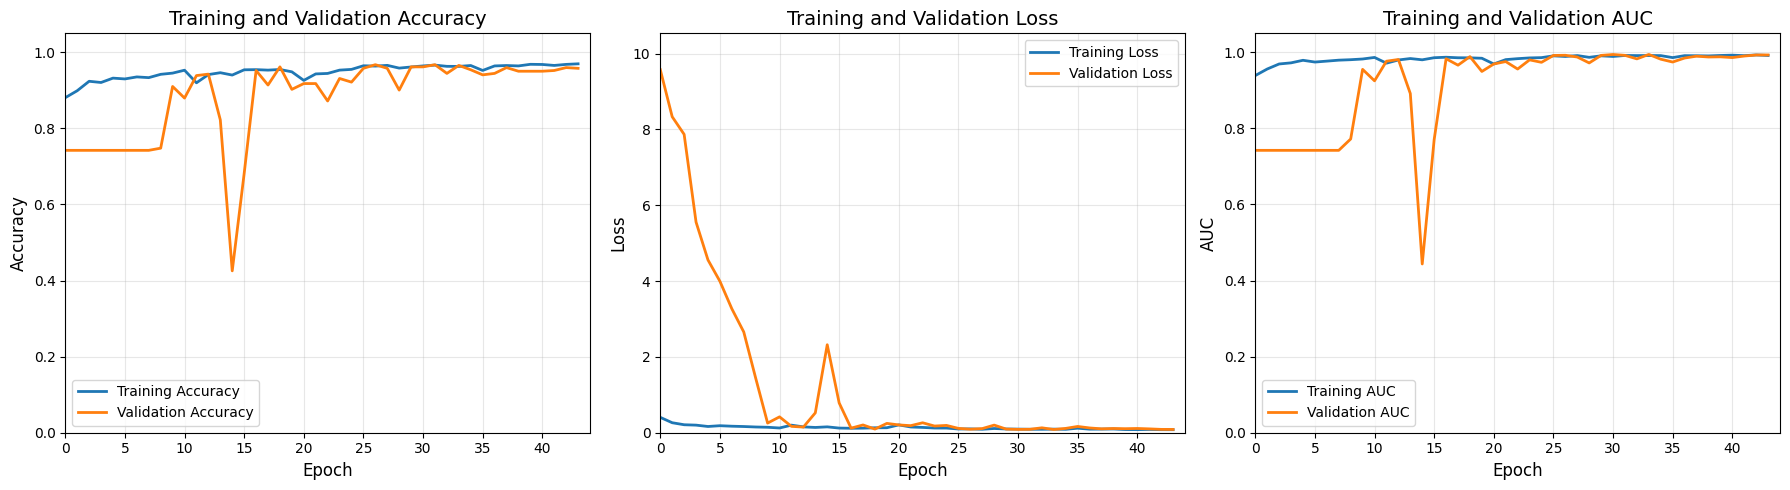

In [83]:
# Plot training history
plot_training_history(history)

## Evaluation

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - AUC: 0.9261 - accuracy: 0.8880 - loss: 0.3650
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step


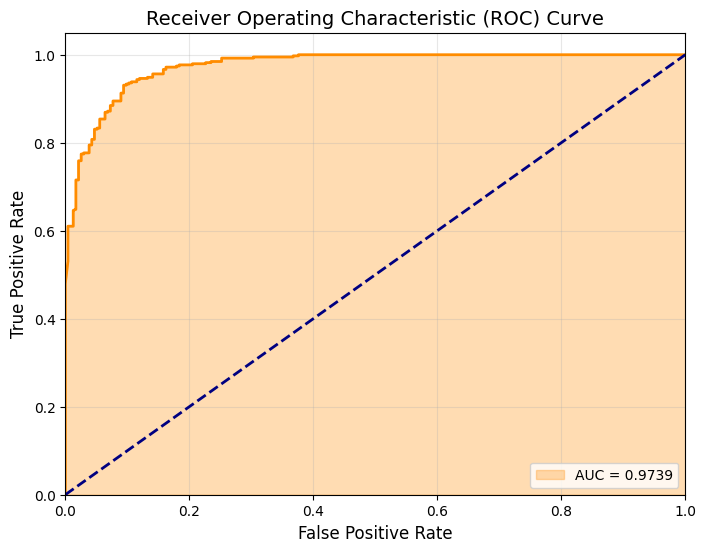

ROC AUC Score: 0.973904


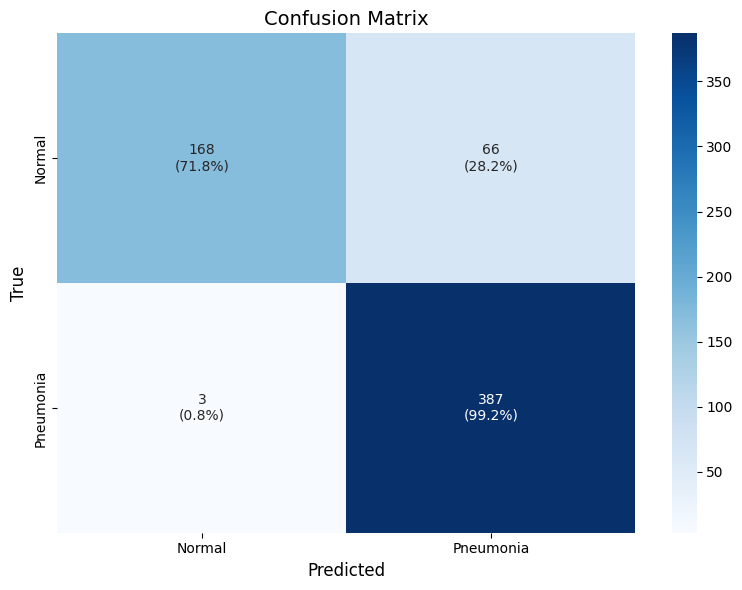

              precision    recall  f1-score   support

      Normal       0.98      0.72      0.83       234
   Pneumonia       0.85      0.99      0.92       390

    accuracy                           0.89       624
   macro avg       0.92      0.86      0.87       624
weighted avg       0.90      0.89      0.88       624



In [84]:
# Evaluate model with reduced verbosity
results = evaluate_model(model, test_images, test_labels, verbose=tf_verbosity)

# Add evaluation results to logger
logger.add_evaluation_results(results)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

## Checkpointing

In [85]:
# Save all model information
logger.save(LOG_PATH)

# Save final model
model.save(FINAL_MODEL_PATH)
print(f"Model saved to {FINAL_MODEL_PATH}")

Run information saved to ../output/logs/alexnet_augmented_info.json
Model saved to ../output/models/alexnet_augmented_b96_lr0.001_dr0.5_0.3_pneumonia_model.keras
